# News Press Releases

In [7]:
import pandas as pd

In [8]:
news_df = pd.read_csv('../datasets/press-releases/news_articles.csv').drop_duplicates()

In [140]:
pr_df = pd.read_csv('../datasets/press-releases/press_releases.csv')

In [10]:
mappings_df = pd.read_csv('../datasets/press-releases/press_release_news_mappings.csv')

In [12]:
news_df.dropna().shape

(341972, 5)

In [13]:
pr_df.dropna().merge(
    mappings_df['press_release_id'].value_counts().to_frame('coverage_counts'),
    left_on='press_release_id',
    right_index=True, 
    how='left',
).fillna(0)['coverage_counts'].value_counts()

coverage_counts
1        62917
2        15385
3         6635
4         3608
5         2358
         ...  
282          1
163          1
19888        1
226          1
303          1
Name: count, Length: 326, dtype: int64

In [14]:
from urllib.parse import urlparse
import tldextract
from tqdm.auto import tqdm

# Basic extraction
ext = tldextract.extract('http://forums.bbc.co.uk')

In [15]:
tqdm.pandas()

In [16]:
news_df['extracts'] = news_df['news_article_url'].progress_apply(tldextract.extract)

  0%|          | 0/567423 [00:00<?, ?it/s]

In [19]:
if 'extracts' in news_df.columns:
    news_df['news_article_domain'] = news_df['extracts'].apply(lambda x: x.domain)
    news_df['news_article_subdomain'] = news_df['extracts'].apply(lambda x: x.subdomain)
    news_df= news_df.drop(columns='extracts')

In [ ]:
t_map = (
    mappings_df
        .merge(pr_df[['press_release_id', 'press_release_url', 'press_release_company']])
        .groupby('news_article_id')[['press_release_id', 'press_release_url', 'press_release_company']].agg(list)
)
single_company_news_articles = t_map['press_release_company'].apply(set).str.len().loc[lambda s: s == 1].index

In [167]:
def identify_xbrl(text):
    # 1. XBRL Data Indicators (Strongly Positive)
    taxonomy_matches = re.findall(r'(us-gaap|dei|srt|iso4217|nws):', text)
    cik_matches = re.findall(r'\b000[0-9]{7}\b', text) # 10-digit SEC ID
    xbrl_attr = re.findall(r'(contextRef|unitRef|decimals|xbrli:)', text)
    
    # 2. Prose/Natural Language Indicators (Strongly Negative)
    # These words are everywhere in articles, but rare in raw data strings.
    prose_words = re.findall(r'\b(the|and|that|was|with|book|author|dear|sincerely|about)\b', text, re.IGNORECASE)
    
    # 3. Calculate Weighted Score
    # Give high value to taxonomy tags, subtract value for common English words
    score = (len(taxonomy_matches) * 10) + (len(cik_matches) * 5) + (len(xbrl_attr) * 10)
    score -= (len(prose_words) * 2)
    
    # 4. Final Verdict
    # A threshold of 20 ensures we only flag heavy data dumps, not just a casual mention.
    is_xbrl = score > 20
    single_company_news_articles
    return {
        "is_xbrl": is_xbrl,
        "confidence_score": score,
        "taxonomy_tags_found": len(taxonomy_matches),
        "prose_word_count": len(prose_words)
    }

In [124]:
identify_xbrl(pr_df.loc[lambda df: df['press_release_company'] == 'newscorp']['press_release_text'].iloc[0])

{'is_xbrl': True,
 'confidence_score': 2032,
 'indicators_found': ['Namespaces',
  'CIK Numbers',
  'Date Ranges',
  'XBRL Context']}

In [128]:
is_xbrl = pd.DataFrame(pr_df['press_release_text'].progress_apply(identify_xbrl).tolist())

  0%|          | 0/171427 [00:00<?, ?it/s]

In [162]:
pr_df = (
    pr_df.loc[~is_xbrl['is_xbrl']]
    .drop_duplicates('press_release_text')
    .loc[lambda df: ~df['press_release_text'].str.contains('We will keep fighting for all libraries')]
    .loc[lambda df: df['press_release_company'] != 'go_factset']
        # .loc[lambda df: df['press_release_company'] != 'go_factset']
)

In [60]:
l = t_map.loc[lambda s: s.str.len() == 2].iloc[6]

In [61]:
pr_df.loc[lambda df: df['press_release_id'].isin(l)]

,press_release_id,press_release_text,press_release_url,press_release_date,press_release_company
53797,53797,A Bullseye View. Behind the scenes at Target ...,https://corporate.target.com/about/purpose-his...,2019-12-19T00:00:00Z,corporate_target
53820,53820,close search panel \nsearch shop with confide...,https://corporate.target.com/about/shopping-ex...,2018-07-15T00:00:00Z,corporate_target


In [207]:
top_domains = news_df['news_article_domain'].value_counts().loc[lambda s: s > 5_000].index

In [208]:
top_news_articles = (
    news_df
    .loc[lambda df: df['news_article_id'].isin(single_company_news_articles)]
    .loc[lambda df: df['news_article_domain'].isin(top_domains)]
)

In [223]:
pr_ids_to_fetch = (
    pr_df[['press_release_id', 'press_release_company']]
         .merge(mappings_df)
         .merge(top_news_articles[['news_article_id', 'news_article_date', 'news_article_domain']])
)

In [225]:
pr_ids_pos = pr_ids_to_fetch.sample(frac=1).drop_duplicates(['news_article_id', 'press_release_company'])

In [226]:
(pr_ids_pos['press_release_id'].value_counts().value_counts()
 # .iloc[1:]
 .sum()#lambda s: s > 1]
)

53780

In [227]:
pr_df.shape

(128131, 5)

In [242]:
press_release_output_df['judgement'].value_counts()

judgement
True     286567
False     74351
Name: count, dtype: int64

In [256]:
pr_ids_pos_to_merge = (
    pr_ids_pos
         .drop_duplicates(['press_release_id', 'press_release_company', 'news_article_id'])# 'news_article_domain'])
         .drop(columns='press_release_company')
         .groupby('press_release_id')[['news_article_id', 'news_article_domain']].agg(list)
)

In [260]:
press_release_output_df = pd.concat([
    (pr_df
         .merge(pr_ids_pos_to_merge.reset_index())
         .assign(judgement=True)
         .rename(columns={'press_release_text':'text'})
    ),
    (pr_df
     .loc[lambda df: ~df['press_release_id'].isin(pr_ids_pos['press_release_id'])]
     .assign(judgement=False)
     .rename(columns={'press_release_text':'text'})
    )
])

In [266]:
press_release_output_df.to_csv('../datasets/press-releases/press_release_modeling_dataset.csv.gz', compression='gzip')

In [275]:
node_path = f"skampere{s_id}-proxy:/lfs/skampere{s_id}/0/alexspan/norm-research/datasets/press-releases/"
! scp -r ../datasets/press-releases/press_release_modeling_dataset.csv.gz $node_path

press_release_modeling_dataset.csv.gz         100%  338MB  28.3MB/s   00:11    


In [274]:
s_id=2
node_path = f"skampere{s_id}-proxy:/lfs/skampere{s_id}/0/alexspan/norm-research/methods/dense/"
! scp -r ../methods/dense/train_reward_model.py $node_path

train_reward_model.py                         100%   20KB   2.7MB/s   00:00    


# Creative Writing

In [276]:
ls ../datasets/creative-writing/LitBench-Test.csv

LitBench-Rationales.csv  LitBench-Test.csv        LitBench-Train.csv


In [285]:
training_df = pd.read_csv('../datasets/creative-writing/LitBench-Train.csv')
full_df = pd.concat([
    training_df,
    # pd.read_csv('../datasets/creative-writing/LitBench-Test.csv')
])

In [286]:
test_df = pd.read_csv('../datasets/creative-writing/LitBench-Test.csv')

In [288]:
test_df.shape

(2381, 2)

In [278]:
training_df.head(2)

,prompt,chosen_story,rejected_story,chosen_timestamp,rejected_timestamp,chosen_upvotes,rejected_upvotes
0,"[WP] In this world, soulmates cannot hurt each...",He was a stage actor and assassin with a cold ...,I was the best. Emphasis on the was. Let's fac...,2018-04-24 04:31:34,2018-04-24 03:48:04,102,22
1,"[WP] You thought you were ordinary, until a ps...","I used to be an ordinary person, until one day...",Life has always made sense for me. Pretty much...,2018-06-23 10:38:47,2018-06-23 08:26:47,65,16


In [279]:
stories_and_votes = pd.concat([
    training_df[['chosen_story', 'chosen_upvotes']].rename(columns=lambda x: x.replace('chosen_', '')),
    training_df[['rejected_story', 'rejected_upvotes']].rename(columns=lambda x: x.replace('rejected_', ''))
])

<Axes: >

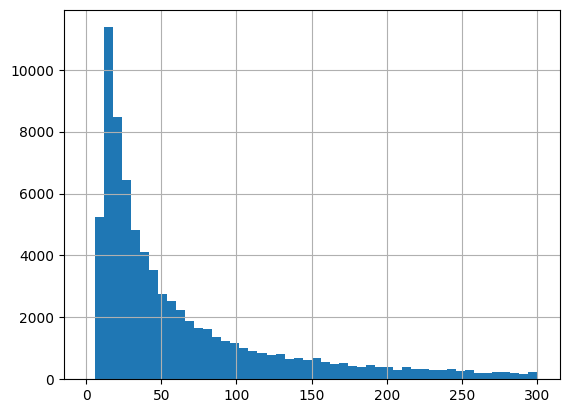

In [57]:
stories_and_votes['upvotes'].hist(bins=50, range=(0, 300))

In [295]:
(
    stories_and_votes
     .rename(columns={'story': 'text'})
     .assign(judgement=lambda df: (df['upvotes'] > 100).astype(int))
    .to_csv('../datasets/creative-writing/litbench-to-train.csv.gz', compression='gzip')
)

# Other datasets to consider

* Code review or pull request acceptance  ✅
    * [GitTorrent](https://www.kaggle.com/datasets/stephangarland/ghtorrent-pull-requests) and [MSR](https://github.com/ghtorrent/ghtorrent.org/blob/master/msr14.md)
* Grant funding decisions: 🟨
    * some decisions exist: [302 grants](https://www.ogrants.org/grants-01-all) and [117 proposals](https://riojournal.com/articles)
* Legal case outcome prediction 🟨
    * [Court Listener](https://www.courtlistener.com/) and [Bulk Data](https://com-courtlistener-storage.s3-us-west-2.amazonaws.com/list.html?prefix=bulk-data/)
* Academic peer review ✅
    * [OpenReview](https://openreview.net/)
    * [AIBS](https://www.aibs.org/spars/open-peer-review-data-sets.html)
    * PeerReview ✅
* Wikipedia editorial decisions
    * [Featured Article Decisions](https://en.wikipedia.org/wiki/Wikipedia:Featured_article_candidates)
    * [Good Article Nominations](https://en.wikipedia.org/wiki/Wikipedia:Good_article_nominations)
* Patent examiner decisions
    * PatentEdits?
* Open source package adoption ❌
    * Will have to binarize data ([link](https://libraries.io/data))
* Which city councils on the same topic get passed into law (or get covered by the media?)
    * If "getting passed into law", then we might want to assess how much text we have overall (including meeting discussions) 🟨
    * If: getting covered by media, I will have to link news articles with city council policies 🟨
* Joke selection 
    * New Yorker Cartoon Caption Contest Dataset ([link](https://huggingface.co/datasets/yguooo/newyorker_caption_ranking)) ✅
    * [Reddit Jokes](https://github.com/orionw/rJokesData) 
* News Articles on Homepages 🟨
    * [News Homepages Dataset](https://aclanthology.org/2025.emnlp-main.1695.pdf)

<!-- Startup investment decisions (?) possibly exists data in crunchbase
https://www.crunchbase.com/buy/select-product-->

In [4]:
ls ../datasets/notes-and-comment/

In [5]:
for s_id in [2, 3]:
    node_path = f"skampere{s_id}-proxy:/lfs/skampere{s_id}/0/alexspan/norm-research"
    ! scp -r ../datasets/creative-writing/ $node_path
    ! scp -r ../datasets/press-releases/*.csv $node_path
    ! scp -r ../methods $node_path

LitBench-Train.csv                            100%  265MB   7.1MB/s   00:37    
LitBench-Rationales.csv                       100%  343MB   6.2MB/s   00:55    
LitBench-Test.csv                             100%   37KB   2.3MB/s   00:00    
news_articles.csv                             100% 3179MB   5.6MB/s   09:26    
press_release_news_mappings.csv               100%   38MB   8.2MB/s   00:04    
press_releases.csv                            100% 1390MB   6.4MB/s   03:38    
reward_model_lora_training_guide.md           100%   23KB   1.8MB/s   00:00    
requirements.txt                              100%  124     9.9KB/s   00:00    
b200_fsdp.yaml                                100%  856    92.4KB/s   00:00    
h200_fsdp.yaml                                100%  858    70.3KB/s   00:00    
train_reward_model.py                         100%   15KB 525.5KB/s   00:00    
LitBench-Train.csv                            100%  265MB   4.8MB/s   00:55    
LitBench-Rationales.csv                 

In [273]:
pwd

'/Users/spangher/Projects/stanford-research/norm-research/notebooks'